Cell 1 — Markdown (click + Markdown)

# Used Car Market Analysis
EDA on the Car Dekho India dataset.  
Questions: What drives resale price? How do fuel type, age, and km affect value?

Cell 2 — Code

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

Cell 3 — Code

In [2]:
df = pd.read_csv("D:/Git/used-car-analysis/data/car_data.csv")
print(df.shape)
df.head()

(301, 9)


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


Cell 4 — Code

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


Cell 5 — Code

In [4]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


Cell 6 — Feature engineering

In [5]:
df["Car_Age"] = 2024 - df["Year"]
df["Depreciation"] = round(
    (df["Present_Price"] - df["Selling_Price"]) / df["Present_Price"] * 100, 2
)
df[["Car_Name", "Year", "Car_Age", "Selling_Price", "Present_Price", "Depreciation"]].head()

,Car_Name,Year,Car_Age,Selling_Price,Present_Price,Depreciation
0,ritz,2014,10,3.35,5.59,40.07
1,sx4,2013,11,4.75,9.54,50.21
2,ciaz,2017,7,7.25,9.85,26.40
3,wagon r,2011,13,2.85,4.15,31.33
4,swift,2014,10,4.60,6.87,33.04


Cell 7 — Outlier check

In [6]:
print("Kms outliers:")
print(df[df["Kms_Driven"] > 200000][["Car_Name", "Kms_Driven", "Selling_Price"]])

Kms outliers:
          Car_Name  Kms_Driven  Selling_Price
179  Honda Karizma      213000           0.31
196      Activa 3g      500000           0.17


Cell 8 — Price distribution

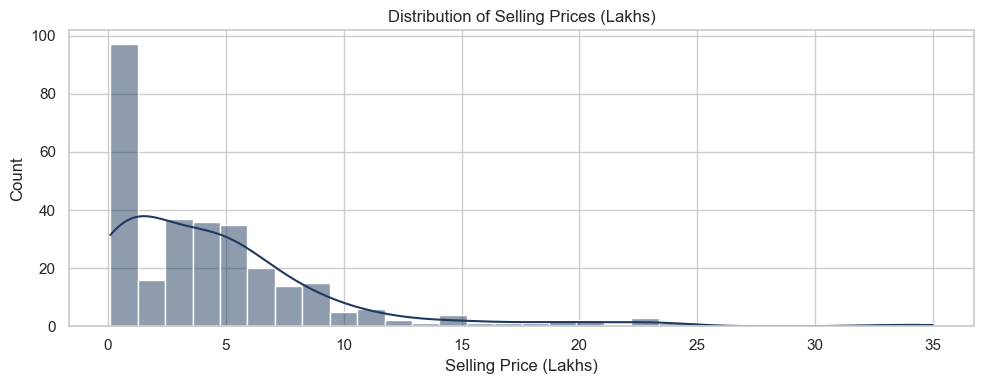

In [7]:
plt.figure(figsize=(10, 4))
sns.histplot(df["Selling_Price"], bins=30, kde=True, color="#1E3A5F")
plt.title("Distribution of Selling Prices (Lakhs)")
plt.xlabel("Selling Price (Lakhs)")
plt.tight_layout()
plt.show()

Cell 9 — Price by fuel type

C:\Users\jayhi\AppData\Local\Temp\ipykernel_41004\3646535661.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Fuel_Type", y="Selling_Price", palette="Set2")


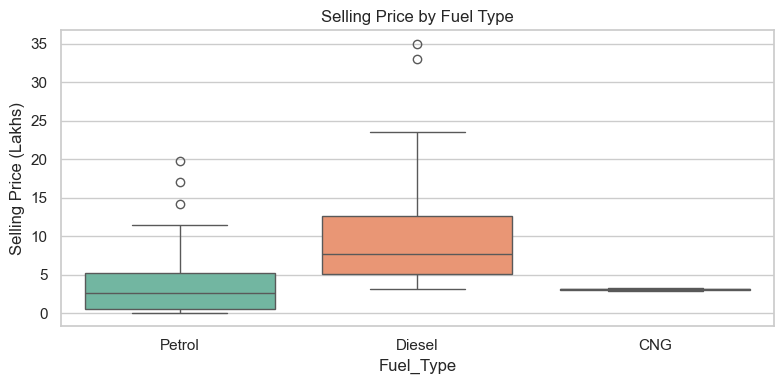

In [8]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="Fuel_Type", y="Selling_Price", palette="Set2")
plt.title("Selling Price by Fuel Type")
plt.ylabel("Selling Price (Lakhs)")
plt.tight_layout()
plt.show()

Cell 10 — Age vs price

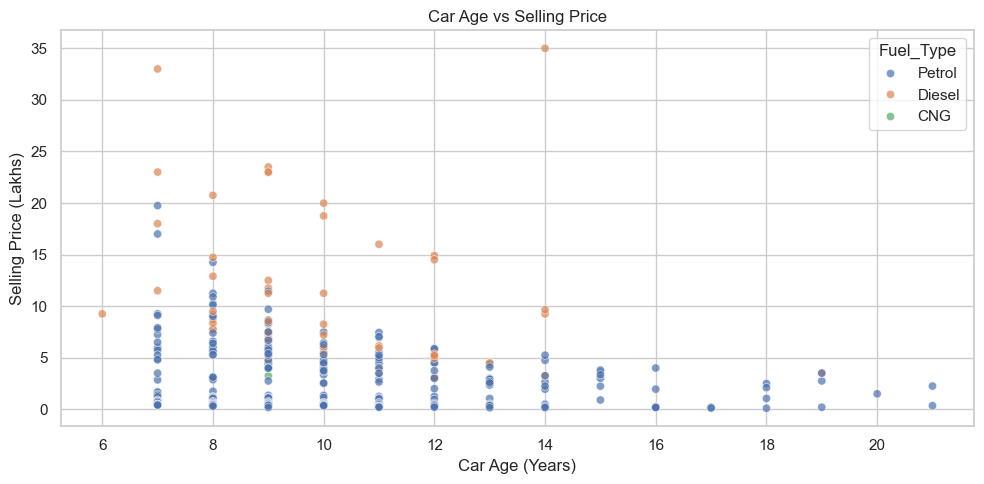

In [9]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x="Car_Age", y="Selling_Price", 
                hue="Fuel_Type", alpha=0.7)
plt.title("Car Age vs Selling Price")
plt.xlabel("Car Age (Years)")
plt.ylabel("Selling Price (Lakhs)")
plt.tight_layout()
plt.show()